# Notebook 07: Sensitivity, Final Report, and Portfolio Artifacts

This is the closing notebook for ** Long-Term Causal Effects in Recommendation Systems**.

The project asked whether short-term recommendation exposure, defined as a high-watch-exposure user-day, appears to change longer-term user engagement in KuaiRec. The previous notebooks built the analysis step by step:

- Notebook 01 created the sequential KuaiRec user-day panel.
- Notebook 02 defined the estimand.
- Notebook 03 modeled time-varying confounding and created stabilized weights.
- Notebook 04 estimated a marginal structural model.
- Notebook 05 estimated g-computation effects.
- Notebook 06 estimated doubly robust AIPW effects and explored heterogeneity.

This final notebook turns those modeling outputs into a concise project conclusion and saves portfolio-ready artifacts: figures, tables, final summary text, limitations, and resume bullets.


## Final Project Question

The final causal question is:

> Among active KuaiRec user-days with sufficient prior history and 7-day follow-up, what is the effect of a high-watch-exposure day on future 7-day interaction volume?

A high-watch-exposure day is not a randomized intervention. It is a constructed treatment from observed behavior. That means every result in this notebook depends on the sequential ignorability assumption: after conditioning on observed user history and calendar context, treated and untreated user-days are comparable enough for causal adjustment.

The final conclusion should therefore be framed as **offline observational evidence**, not as a substitute for an online experiment.


## Setup

The first cell imports libraries for loading final artifacts, creating report tables, saving figures, and writing markdown summaries. The final notebook should be deterministic and lightweight because it does not refit the main causal models.


In [1]:
from pathlib import Path
import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")


The notebook environment is ready for reporting. No causal model is being refit here; the goal is to assemble and communicate the evidence produced by the earlier notebooks.


## Locate Project Inputs and Report Folders

This cell finds the project root, checks for the final estimator comparison table, and creates the final `writeup` folders for figures and tables.


In [2]:
FINAL_COMPARISON_RELATIVE_PATH = Path("data/processed/kuairec_long_term_estimator_comparison_with_aipw.csv")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / FINAL_COMPARISON_RELATIVE_PATH).exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find {FINAL_COMPARISON_RELATIVE_PATH}. Run Notebooks 04-06 first or run this notebook inside the project."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
WRITEUP_DIR = PROJECT_ROOT / "notebooks" / "long_term_causal_effects" / "writeup"
FIGURES_DIR = WRITEUP_DIR / "figures"
TABLES_DIR = WRITEUP_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data folder: {PROCESSED_DIR}")
print(f"Writeup folder: {WRITEUP_DIR}")
print(f"Figures folder: {FIGURES_DIR}")
print(f"Tables folder: {TABLES_DIR}")


Project root: /home/apex/Documents/ranking_sys
Processed data folder: /home/apex/Documents/ranking_sys/data/processed
Writeup folder: /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup
Figures folder: /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/figures
Tables folder: /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/tables


The writeup folder structure is now ready. The rest of the notebook will save final tables and figures into this project-specific report location.


## Load Final Project Artifacts

The final report combines artifacts from all modeling notebooks. This cell loads the estimator comparison, weight diagnostics, balance diagnostics, sensitivity outputs, secondary outcome outputs, heterogeneity tables, and effect moderator importances.


In [3]:
def read_processed_csv(filename):
    path = PROCESSED_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing required artifact: {path}")
    return pd.read_csv(path)

estimator_comparison = read_processed_csv("kuairec_long_term_estimator_comparison_with_aipw.csv")
weight_readiness = read_processed_csv("kuairec_long_term_weight_readiness_checks.csv")
balance_diagnostics = read_processed_csv("kuairec_long_term_balance_diagnostics.csv")
weight_diagnostics = read_processed_csv("kuairec_long_term_weight_diagnostics.csv")
msm_weight_sensitivity = read_processed_csv("kuairec_long_term_msm_weight_sensitivity.csv")
msm_secondary = read_processed_csv("kuairec_long_term_msm_secondary_outcomes.csv")
gcomp_secondary = read_processed_csv("kuairec_long_term_gcomp_secondary_outcomes.csv")
aipw_segment_effects = read_processed_csv("kuairec_long_term_aipw_segment_effects.csv")
effect_importance = read_processed_csv("kuairec_long_term_effect_moderator_importance.csv")
smoothed_effect_buckets = read_processed_csv("kuairec_long_term_smoothed_effect_buckets.csv")
propensity_metrics = read_processed_csv("kuairec_long_term_propensity_model_metrics.csv")
gcomp_metrics = read_processed_csv("kuairec_long_term_gcomp_model_metrics.csv")
aipw_results = read_processed_csv("kuairec_long_term_aipw_results.csv")

artifact_shapes = pd.DataFrame(
    [
        {"artifact": "estimator_comparison", "rows": len(estimator_comparison), "columns": estimator_comparison.shape[1]},
        {"artifact": "weight_readiness", "rows": len(weight_readiness), "columns": weight_readiness.shape[1]},
        {"artifact": "balance_diagnostics", "rows": len(balance_diagnostics), "columns": balance_diagnostics.shape[1]},
        {"artifact": "msm_weight_sensitivity", "rows": len(msm_weight_sensitivity), "columns": msm_weight_sensitivity.shape[1]},
        {"artifact": "msm_secondary", "rows": len(msm_secondary), "columns": msm_secondary.shape[1]},
        {"artifact": "gcomp_secondary", "rows": len(gcomp_secondary), "columns": gcomp_secondary.shape[1]},
        {"artifact": "aipw_segment_effects", "rows": len(aipw_segment_effects), "columns": aipw_segment_effects.shape[1]},
        {"artifact": "effect_importance", "rows": len(effect_importance), "columns": effect_importance.shape[1]},
    ]
)

display(artifact_shapes)


,artifact,rows,columns
0,estimator_comparison,4,7
1,weight_readiness,5,3
2,balance_diagnostics,12,10
3,msm_weight_sensitivity,7,16
4,msm_secondary,4,14
5,gcomp_secondary,4,9
6,aipw_segment_effects,23,16
7,effect_importance,19,2


All final artifacts loaded successfully. The report can now synthesize the project instead of recomputing models.


## Create the Final Estimator Comparison Table

The main project result is a cross-estimator comparison. This table includes MSM, g-computation, and doubly robust AIPW estimates on the same outcome scale: future 7-day interactions.


In [4]:
def clean_method_label(row):
    if row["method"].startswith("MSM"):
        return "MSM, weighted"
    if row["method"] == "G-computation" and row["model"] == "lightgbm":
        return "G-computation, LightGBM"
    if row["method"] == "G-computation" and row["model"] == "linear_ridge":
        return "G-computation, linear"
    if row["method"].startswith("Doubly robust"):
        return "AIPW, doubly robust"
    return f"{row['method']}, {row['model']}"

final_estimator_table = estimator_comparison.copy()
final_estimator_table["estimator"] = final_estimator_table.apply(clean_method_label, axis=1)
final_estimator_table["relative_lift_pct"] = 100 * final_estimator_table["relative_lift_vs_msm_control_mean"]
final_estimator_table = final_estimator_table[
    [
        "estimator",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "relative_lift_pct",
        "source",
    ]
].copy()

final_estimator_table["conclusion"] = np.where(
    (final_estimator_table["ci_95_lower"] <= 0) & (final_estimator_table["ci_95_upper"] >= 0),
    "interval crosses zero",
    "interval excludes zero",
)

final_estimator_table.to_csv(TABLES_DIR / "final_estimator_comparison.csv", index=False)
display(final_estimator_table)


,estimator,estimate,ci_95_lower,ci_95_upper,relative_lift_pct,source,conclusion
0,"MSM, weighted",-2.6877,-12.2706,5.7291,-0.7164,Notebook 04 user-cluster bootstrap,interval crosses zero
1,"G-computation, LightGBM",0.0359,-0.6384,1.8656,0.0096,Notebook 05 user-cluster bootstrap,interval crosses zero
2,"G-computation, linear",2.3288,-6.3238,9.3565,0.6208,Notebook 05 user-cluster bootstrap,interval crosses zero
3,"AIPW, doubly robust",1.0940,-7.3428,12.0178,0.2916,Notebook 06 user-cluster bootstrap over AIPW s...,interval crosses zero


The final comparison table shows the central project conclusion: every main estimator has an interval that crosses zero. The average effect is small and uncertain across weighting, outcome modeling, and doubly robust approaches.


## Figure 1: Final Estimator Comparison

This figure is the most important visual artifact for the project. It shows the estimated effect of high-watch exposure on future 7-day interactions across all main estimators.


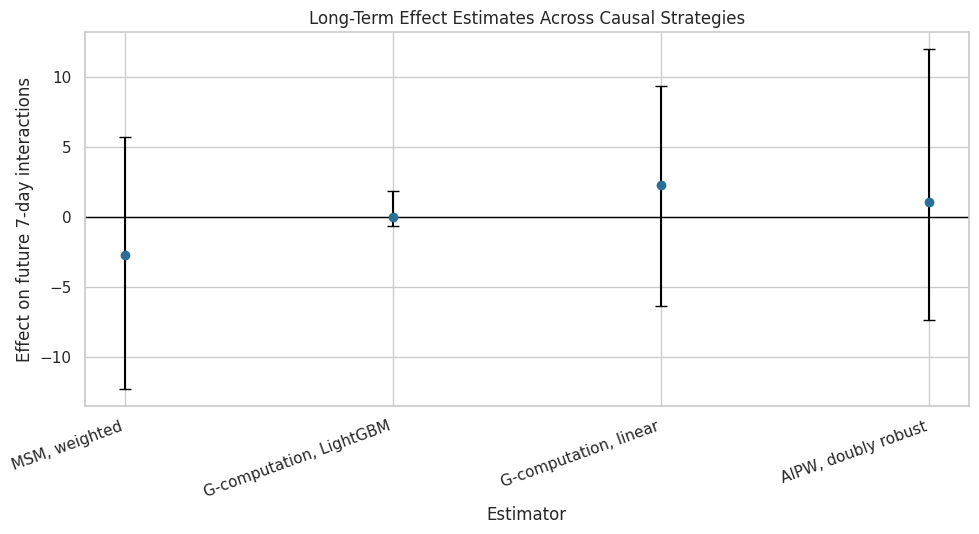

Saved /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/figures/01_estimator_comparison.png


In [5]:
plot_df = final_estimator_table.copy()
plot_df["lower_error"] = plot_df["estimate"] - plot_df["ci_95_lower"]
plot_df["upper_error"] = plot_df["ci_95_upper"] - plot_df["estimate"]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["estimate"],
    yerr=[plot_df["lower_error"], plot_df["upper_error"]],
    fmt="o",
    color="#2A6F97",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(plot_df["estimator"], rotation=20, ha="right")
ax.set_title("Long-Term Effect Estimates Across Causal Strategies")
ax.set_ylabel("Effect on future 7-day interactions")
ax.set_xlabel("Estimator")
plt.tight_layout()
figure_path = FIGURES_DIR / "01_estimator_comparison.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved {figure_path}")


The figure makes the cross-method conclusion visually clear. The estimates cluster near zero and the uncertainty intervals cross zero, so the final report should not claim a reliable average long-term lift.


## Weight and Overlap Readiness Summary

The treatment weighting notebook showed that observed balance improved after weighting, but overlap was not perfect. This table summarizes the readiness checks that matter for interpreting the MSM result.


In [6]:
weight_readiness_report = weight_readiness.copy()
weight_readiness_report["status"] = np.where(weight_readiness_report["passes"], "passes", "caution")
weight_readiness_report.to_csv(TABLES_DIR / "weight_readiness_checks.csv", index=False)

display(weight_readiness_report)

display(weight_diagnostics)


,check,value,passes,status
0,no propensity below 0.05 or above 0.95 for mos...,0.0664,False,caution
1,analysis weight max below clipping cap,10.0000,True,passes
2,effective sample size at least 70% of rows,0.5110,False,caution
3,mean absolute SMD improves after weighting,0.3311,True,passes
4,maximum absolute SMD improves after weighting,1.1915,True,passes


,weight,mean,std,min,p50,p90,p95,p99,max,effective_sample_size,ess_share_of_rows
0,ipw_logistic,2.0767,3.4301,1.0028,1.3945,3.2625,4.7814,11.4275,119.9903,"1,260.3721",0.2683
1,sw_logistic,1.0384,1.7153,0.5018,0.6973,1.6307,2.3921,5.7092,59.9441,"1,260.0838",0.2682
2,ipw_lightgbm,2.0541,2.2425,1.0216,1.3874,3.3732,5.1568,11.7539,45.0967,"2,143.6149",0.4563
3,sw_lightgbm,1.0270,1.1213,0.5104,0.6935,1.6872,2.5799,5.8723,22.5676,"2,143.4028",0.4562


The readiness table gives the correct caution language for the final report: weights greatly improved observed balance, but overlap and effective sample size were imperfect. That limits how strongly the MSM result should be interpreted.


## Figure 2: Covariate Balance Before and After Weighting

This figure shows whether the stabilized weights reduced observed treated-control imbalance on pre-treatment histories.


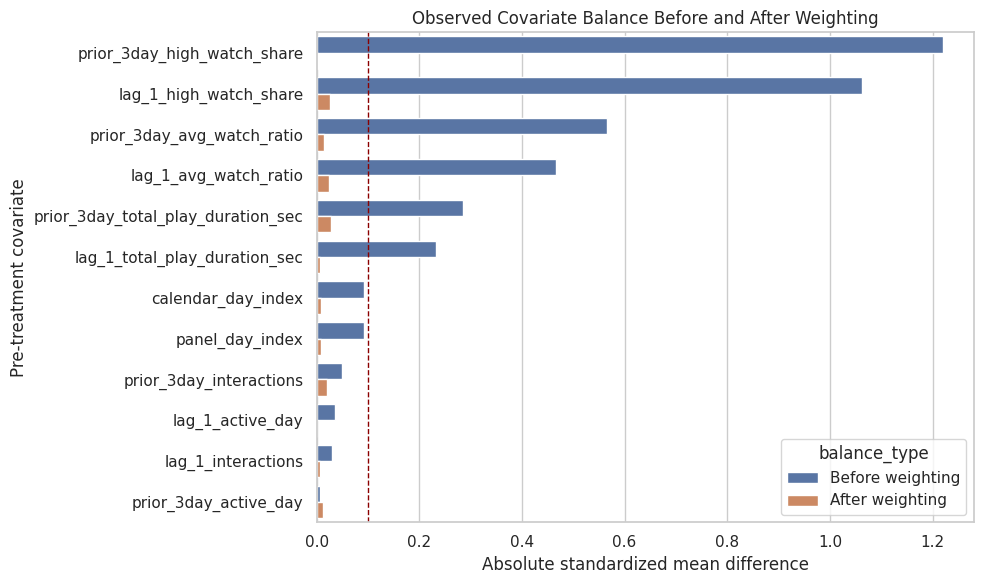

Saved /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/figures/02_weight_balance.png


In [7]:
balance_plot = balance_diagnostics[
    ["covariate", "abs_smd_unweighted", "abs_smd_weighted"]
].melt(
    id_vars="covariate",
    var_name="balance_type",
    value_name="absolute_smd",
)
balance_plot["balance_type"] = balance_plot["balance_type"].map(
    {
        "abs_smd_unweighted": "Before weighting",
        "abs_smd_weighted": "After weighting",
    }
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=balance_plot, x="absolute_smd", y="covariate", hue="balance_type", ax=ax)
ax.axvline(0.1, color="darkred", linestyle="--", linewidth=1)
ax.set_title("Observed Covariate Balance Before and After Weighting")
ax.set_xlabel("Absolute standardized mean difference")
ax.set_ylabel("Pre-treatment covariate")
plt.tight_layout()
figure_path = FIGURES_DIR / "02_weight_balance.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved {figure_path}")


The balance figure shows that the weighting step did what it was supposed to do on observed covariates. This supports the MSM analysis, while the overlap diagnostics still justify caution.


## Weight Sensitivity Summary

This table shows how the MSM estimate changed across unweighted, unclipped, clipped, logistic-weighted, and LightGBM-weighted specifications.


In [8]:
weight_sensitivity_report = msm_weight_sensitivity[
    [
        "model",
        "weight_column",
        "treatment_effect",
        "ci_95_lower",
        "ci_95_upper",
        "relative_lift_vs_control",
        "effective_sample_size",
        "ess_share_of_rows",
    ]
].copy()
weight_sensitivity_report["relative_lift_pct"] = 100 * weight_sensitivity_report["relative_lift_vs_control"]
weight_sensitivity_report.to_csv(TABLES_DIR / "msm_weight_sensitivity.csv", index=False)

display(weight_sensitivity_report)


,model,weight_column,treatment_effect,ci_95_lower,ci_95_upper,relative_lift_vs_control,effective_sample_size,ess_share_of_rows,relative_lift_pct
0,unweighted,none,-2.6193,-11.5474,6.3088,-0.0069,"4,698.0000",1.0000,-0.6919
1,logistic_stabilized_unclipped,sw_logistic,1.5616,-14.7943,17.9175,0.0042,"1,260.0838",0.2682,0.4157
2,logistic_stabilized_clip_10,analysis_weight,-2.6877,-11.8189,6.4435,-0.0072,"2,400.8979",0.5110,-0.7164
3,logistic_stabilized_clip_5,sw_logistic_clip_5,-2.9769,-11.1777,5.2239,-0.0079,"2,932.2499",0.6241,-0.7936
4,logistic_stabilized_clip_2,sw_logistic_clip_2,-2.2273,-9.8650,5.4105,-0.0059,"3,797.3068",0.8083,-0.5918
5,lightgbm_stabilized_unclipped,sw_lightgbm,0.9744,-8.5678,10.5166,0.0026,"2,143.4028",0.4562,0.2564
6,lightgbm_stabilized_clip_10,sw_lightgbm_clip_10,-0.4889,-9.4432,8.4655,-0.0013,"2,351.8214",0.5006,-0.1283


The sensitivity table shows that the estimated effect remains small across weight choices, although precision changes with clipping and effective sample size. This supports a cautious near-zero average-effect conclusion.


## Figure 3: MSM Weight Sensitivity

This plot visualizes the MSM treatment effect across weight specifications. It is a useful final-report figure because it shows the result is not driven by one arbitrary clipping choice.


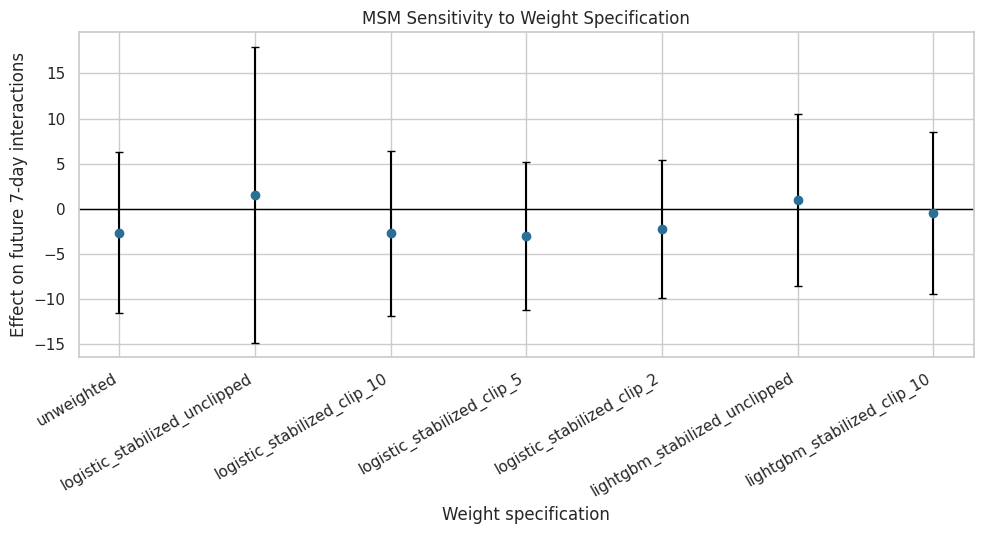

Saved /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/figures/03_weight_sensitivity.png


In [9]:
weight_plot = weight_sensitivity_report.copy()
weight_plot["lower_error"] = weight_plot["treatment_effect"] - weight_plot["ci_95_lower"]
weight_plot["upper_error"] = weight_plot["ci_95_upper"] - weight_plot["treatment_effect"]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(
    x=np.arange(len(weight_plot)),
    y=weight_plot["treatment_effect"],
    yerr=[weight_plot["lower_error"], weight_plot["upper_error"]],
    fmt="o",
    color="#2A6F97",
    ecolor="black",
    capsize=3,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(weight_plot)))
ax.set_xticklabels(weight_plot["model"], rotation=30, ha="right")
ax.set_title("MSM Sensitivity to Weight Specification")
ax.set_ylabel("Effect on future 7-day interactions")
ax.set_xlabel("Weight specification")
plt.tight_layout()
figure_path = FIGURES_DIR / "03_weight_sensitivity.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved {figure_path}")


The sensitivity plot reinforces the main conclusion: the point estimates move somewhat, but they remain small relative to the outcome scale and uncertainty generally overlaps zero.


## Secondary Outcome Summary

The primary outcome is future 7-day interaction volume. The project also checked active days, average daily interactions, watch hours, and log interaction volume. This table combines MSM and g-computation secondary outcome estimates.


In [10]:
msm_secondary_report = msm_secondary[
    ["outcome", "treatment_effect", "ci_95_lower", "ci_95_upper", "relative_lift_vs_control"]
].copy()
msm_secondary_report["estimator"] = "MSM"
msm_secondary_report = msm_secondary_report.rename(columns={"treatment_effect": "estimate", "relative_lift_vs_control": "relative_lift"})

gcomp_secondary_report = gcomp_secondary[
    ["outcome", "ate", "relative_lift_vs_y0"]
].copy()
gcomp_secondary_report["estimator"] = "G-computation, LightGBM"
gcomp_secondary_report = gcomp_secondary_report.rename(columns={"ate": "estimate", "relative_lift_vs_y0": "relative_lift"})
gcomp_secondary_report["ci_95_lower"] = np.nan
gcomp_secondary_report["ci_95_upper"] = np.nan

secondary_report = pd.concat(
    [msm_secondary_report, gcomp_secondary_report],
    ignore_index=True,
    sort=False,
)
secondary_report["relative_lift_pct"] = 100 * secondary_report["relative_lift"]
secondary_report.to_csv(TABLES_DIR / "secondary_outcome_summary.csv", index=False)

display(secondary_report)


,outcome,estimate,ci_95_lower,ci_95_upper,relative_lift,estimator,relative_lift_pct
0,future_7day_active_days,-0.0299,-0.0677,0.0079,-0.0044,MSM,-0.4351
1,future_7day_avg_daily_interactions,-0.3840,-1.6884,0.9205,-0.0072,MSM,-0.7164
2,future_7day_play_hours,0.0598,0.0210,0.0986,0.0689,MSM,6.8882
3,outcome_log1p,-0.0120,-0.0414,0.0175,-0.0021,MSM,-0.2056
4,future_7day_active_days,-0.0176,NaN,NaN,-0.0026,"G-computation, LightGBM",-0.2569
5,future_7day_avg_daily_interactions,0.0051,NaN,NaN,0.0001,"G-computation, LightGBM",0.0094
6,future_7day_play_hours,0.0396,NaN,NaN,0.0441,"G-computation, LightGBM",4.4138
7,outcome_log1p,0.0003,NaN,NaN,0.0001,"G-computation, LightGBM",0.0056


The secondary outcomes add nuance. Interaction volume does not show a clear average effect, while watch-hours estimates are more positive. The final report should distinguish these outcome families rather than collapse them into one engagement story.


## Figure 4: Secondary Outcome Effects

This plot focuses on MSM secondary outcomes because they include uncertainty intervals. It shows whether the treatment appears different for retention-style, interaction-volume, and watch-time metrics.


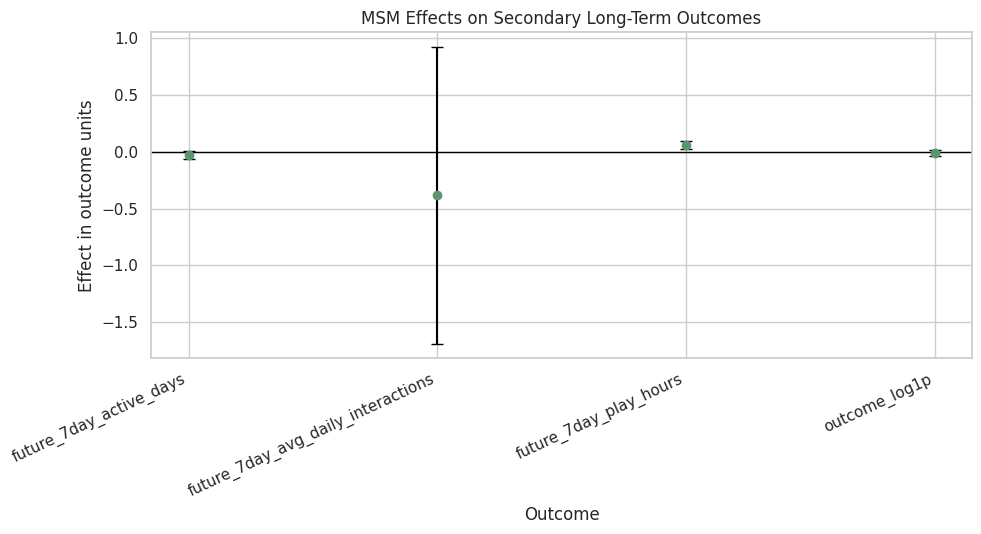

Saved /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/figures/04_secondary_outcomes.png


In [11]:
secondary_msm_plot = msm_secondary_report.copy()
secondary_msm_plot["lower_error"] = secondary_msm_plot["estimate"] - secondary_msm_plot["ci_95_lower"]
secondary_msm_plot["upper_error"] = secondary_msm_plot["ci_95_upper"] - secondary_msm_plot["estimate"]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(
    x=np.arange(len(secondary_msm_plot)),
    y=secondary_msm_plot["estimate"],
    yerr=[secondary_msm_plot["lower_error"], secondary_msm_plot["upper_error"]],
    fmt="o",
    color="#5C946E",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(secondary_msm_plot)))
ax.set_xticklabels(secondary_msm_plot["outcome"], rotation=25, ha="right")
ax.set_title("MSM Effects on Secondary Long-Term Outcomes")
ax.set_ylabel("Effect in outcome units")
ax.set_xlabel("Outcome")
plt.tight_layout()
figure_path = FIGURES_DIR / "04_secondary_outcomes.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved {figure_path}")


The secondary-outcome plot shows why the final conclusion should be precise. There is no clear interaction-volume gain, but watch-time-oriented outcomes may move differently and deserve separate validation.


## Heterogeneous Effects Summary

Notebook 06 explored whether the near-zero average effect hides segment-level variation. This cell creates a final table of the most positive and most negative segment estimates that pass the size filter.


In [12]:
eligible_segments = aipw_segment_effects.query("passes_size_filter == True").copy()
eligible_segments["interval_crosses_zero"] = (eligible_segments["ci_95_lower"] <= 0) & (eligible_segments["ci_95_upper"] >= 0)

most_positive_segments = eligible_segments.sort_values("aipw_ate", ascending=False).head(8)
most_negative_segments = eligible_segments.sort_values("aipw_ate", ascending=True).head(8)
final_segment_report = pd.concat(
    [
        most_positive_segments.assign(direction="most_positive"),
        most_negative_segments.assign(direction="most_negative"),
    ],
    ignore_index=True,
)

final_segment_report.to_csv(TABLES_DIR / "heterogeneous_segment_effects.csv", index=False)
display(final_segment_report)


,segment_type,segment,rows,users,treatment_rate,observed_outcome_mean,aipw_ate,aipw_score_std,gcomp_component,mean_propensity,passes_size_filter,bootstrap_reps,bootstrap_mean,bootstrap_std,ci_95_lower,ci_95_upper,interval_crosses_zero,direction
0,prior_interactions_bucket,"(217.0, 581.0]",1169,91,0.4688,445.8435,25.6170,548.5773,0.1569,0.4787,True,250,25.7353,17.6855,1.8847,66.3297,False,most_positive
1,day_of_week,Tuesday,623,91,0.4912,390.4575,20.0321,750.2361,0.0096,0.4917,True,250,20.4314,32.7418,-24.3380,90.8593,True,most_positive
2,lag_interactions_bucket,"(75.0, 375.0]",1146,91,0.4852,448.0070,16.2174,575.5850,0.0829,0.4860,True,250,16.0696,18.4124,-9.9926,57.4826,True,most_positive
3,prior_watch_ratio_bucket,"(-0.001, 2.26]",1175,75,0.2119,371.7200,12.7319,549.7271,0.1169,0.2241,True,250,12.4139,17.3878,-9.3683,52.2110,True,most_positive
4,prior_high_watch_bucket,"(-0.001, 1.127]",1175,73,0.1677,368.0732,12.5337,549.1163,0.0551,0.1685,True,250,11.9216,17.3031,-11.3159,52.9259,True,most_positive
5,prior_watch_ratio_bucket,"(2.26, 2.59]",1174,89,0.4421,376.9199,4.2636,157.1119,0.1366,0.4355,True,250,3.9070,5.0899,-5.4912,13.3243,True,most_positive
6,prior_high_watch_bucket,"(1.127, 1.414]",1174,84,0.3424,386.3526,2.4564,154.8324,0.1259,0.3521,True,250,2.5918,4.6737,-6.3520,12.5274,True,most_positive
7,day_of_week,Wednesday,711,91,0.4684,383.1899,1.8366,168.8665,0.0151,0.4673,True,250,2.1471,7.8816,-12.4635,18.6481,True,most_positive
8,prior_watch_ratio_bucket,"(3.004, 11.372]",1175,73,0.6894,388.3106,-13.2926,268.3096,-0.0665,0.7063,True,250,-13.5921,7.0527,-27.1569,-0.8128,False,most_negative
9,prior_interactions_bucket,"(166.0, 217.0]",1164,91,0.5198,420.7345,-12.4330,205.3765,0.0244,0.5120,True,250,-12.2267,6.6019,-26.7004,0.3019,True,most_negative


The segment table is best read as hypothesis generation. Some segments have larger point estimates, but many intervals are wide, so these are candidates for future experiment design rather than deployment rules.


## Figure 5: Prior-Interaction Segment Effects

This figure summarizes AIPW effects across prior 3-day interaction buckets. It asks whether recent engagement level moderates the effect of high-watch exposure.


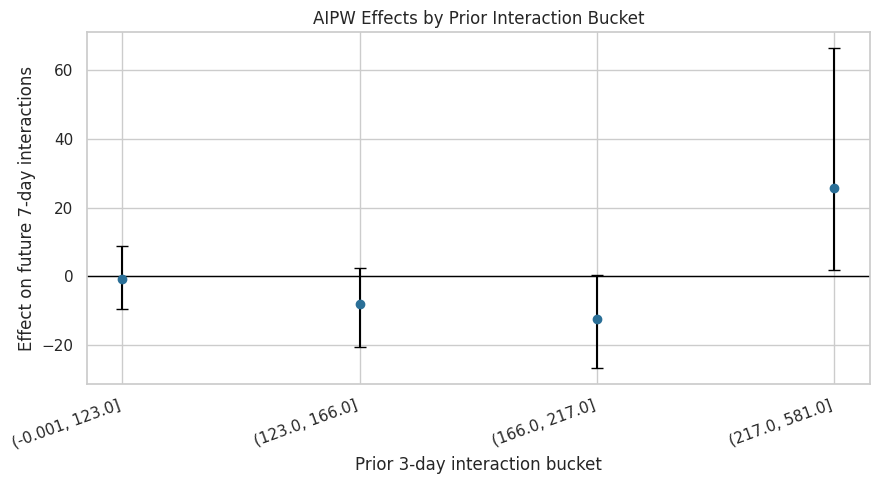

Saved /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/figures/05_prior_interaction_segments.png


In [13]:
prior_interaction_plot = eligible_segments.query("segment_type == 'prior_interactions_bucket'").copy()
prior_interaction_plot = prior_interaction_plot.sort_values("segment")
prior_interaction_plot["lower_error"] = prior_interaction_plot["aipw_ate"] - prior_interaction_plot["ci_95_lower"]
prior_interaction_plot["upper_error"] = prior_interaction_plot["ci_95_upper"] - prior_interaction_plot["aipw_ate"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    x=np.arange(len(prior_interaction_plot)),
    y=prior_interaction_plot["aipw_ate"],
    yerr=[prior_interaction_plot["lower_error"], prior_interaction_plot["upper_error"]],
    fmt="o",
    color="#2A6F97",
    ecolor="black",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(np.arange(len(prior_interaction_plot)))
ax.set_xticklabels(prior_interaction_plot["segment"], rotation=20, ha="right")
ax.set_title("AIPW Effects by Prior Interaction Bucket")
ax.set_xlabel("Prior 3-day interaction bucket")
ax.set_ylabel("Effect on future 7-day interactions")
plt.tight_layout()
figure_path = FIGURES_DIR / "05_prior_interaction_segments.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved {figure_path}")


This plot is a useful product diagnostic. It suggests where the effect may differ by recent activity, but wide intervals mean segment findings should be positioned as experimentation hypotheses.


## Figure 6: Effect Moderator Importance

The effect-smoothing model from Notebook 06 predicts noisy AIPW scores from pre-treatment histories. Feature importance helps identify which histories are most useful for summarizing heterogeneity.


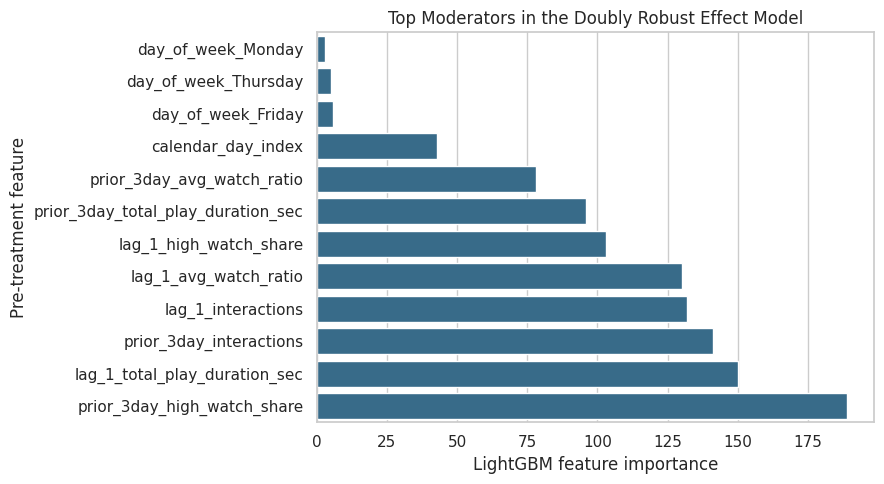

Saved /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/figures/06_effect_moderator_importance.png


In [14]:
importance_plot = effect_importance.head(12).sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=importance_plot, x="importance", y="feature", ax=ax, color="#2A6F97")
ax.set_title("Top Moderators in the Doubly Robust Effect Model")
ax.set_xlabel("LightGBM feature importance")
ax.set_ylabel("Pre-treatment feature")
plt.tight_layout()
figure_path = FIGURES_DIR / "06_effect_moderator_importance.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved {figure_path}")

effect_importance.to_csv(TABLES_DIR / "effect_moderator_importance.csv", index=False)


The moderator importance plot points to recent watch quality and recent activity as the main heterogeneity drivers. These variables are natural stratification candidates for any follow-up online test.


## Final Limitations Table

A strong causal portfolio project should be explicit about what the analysis cannot prove. This cell writes the final limitations table for the project report.


In [15]:
limitations = pd.DataFrame(
    [
        {
            "limitation": "Observational logging",
            "why_it_matters": "High-watch exposure was not randomized, so causal validity depends on observed adjustment rather than experimental assignment.",
            "mitigation_in_project": "Used sequential history covariates, propensity weights, MSM, g-computation, and AIPW triangulation.",
        },
        {
            "limitation": "Sequential ignorability assumption",
            "why_it_matters": "Unobserved user intent or recommender state may affect both treatment and future engagement.",
            "mitigation_in_project": "Adjusted for lagged activity, prior 3-day engagement, watch behavior, and calendar context; documented remaining risk.",
        },
        {
            "limitation": "Imperfect overlap",
            "why_it_matters": "Some histories were much more likely to receive treatment, making weighted estimates less precise.",
            "mitigation_in_project": "Diagnosed positivity, clipped weights, reported effective sample size, and ran weight sensitivity checks.",
        },
        {
            "limitation": "Constructed treatment",
            "why_it_matters": "High-watch exposure is derived from observed consumption, not a product intervention directly assigned by the platform.",
            "mitigation_in_project": "Defined the estimand explicitly and framed conclusions as offline evidence for future experiment design.",
        },
        {
            "limitation": "Dataset slice",
            "why_it_matters": "The analysis uses a KuaiRec sample/panel derived for notebook runtime, so estimates may differ on the full platform log.",
            "mitigation_in_project": "Saved a reproducible panel and designed the workflow so the sample size can be expanded later.",
        },
        {
            "limitation": "Outcome choice",
            "why_it_matters": "Future interactions, active days, and watch hours capture different long-term product objectives.",
            "mitigation_in_project": "Reported primary and secondary outcomes separately instead of forcing one engagement narrative.",
        },
    ]
)

limitations.to_csv(TABLES_DIR / "limitations.csv", index=False)
display(limitations)


,limitation,why_it_matters,mitigation_in_project
0,Observational logging,"High-watch exposure was not randomized, so cau...","Used sequential history covariates, propensity..."
1,Sequential ignorability assumption,Unobserved user intent or recommender state ma...,"Adjusted for lagged activity, prior 3-day enga..."
2,Imperfect overlap,Some histories were much more likely to receiv...,"Diagnosed positivity, clipped weights, reporte..."
3,Constructed treatment,High-watch exposure is derived from observed c...,Defined the estimand explicitly and framed con...
4,Dataset slice,The analysis uses a KuaiRec sample/panel deriv...,Saved a reproducible panel and designed the wo...
5,Outcome choice,"Future interactions, active days, and watch ho...",Reported primary and secondary outcomes separa...


The limitations table keeps the final conclusion honest. The project provides strong offline causal analysis, but the right production next step would still be an online experiment or a logging-policy design with better randomization.


## Final Recommendation Table

This table translates the analysis into a product-facing conclusion. It states what the evidence supports, what it does not support, and what a next experiment should test.


In [16]:
primary_aipw_estimate = final_estimator_table.query("estimator == 'AIPW, doubly robust'")["estimate"].iloc[0]
primary_aipw_low = final_estimator_table.query("estimator == 'AIPW, doubly robust'")["ci_95_lower"].iloc[0]
primary_aipw_high = final_estimator_table.query("estimator == 'AIPW, doubly robust'")["ci_95_upper"].iloc[0]

final_recommendation = pd.DataFrame(
    [
        {
            "decision_area": "Average long-term interaction effect",
            "recommendation": "Do not claim a clear positive average effect from high-watch-exposure days on future 7-day interactions.",
            "evidence": f"MSM, g-computation, and AIPW estimates are small; primary AIPW is {primary_aipw_estimate:.2f} with CI [{primary_aipw_low:.2f}, {primary_aipw_high:.2f}].",
        },
        {
            "decision_area": "Metric strategy",
            "recommendation": "Keep validating watch-time-like signals against longer-term outcomes rather than optimizing them alone.",
            "evidence": "Primary interaction-volume effects are uncertain, while secondary watch-hours results differ from interaction-volume results.",
        },
        {
            "decision_area": "Experiment design",
            "recommendation": "Use recent engagement and watch-quality histories as stratification variables in a future online test.",
            "evidence": "Heterogeneity diagnostics identify recent interactions and high-watch share as important effect moderators.",
        },
        {
            "decision_area": "Deployment posture",
            "recommendation": "Treat this as offline evidence for experiment prioritization, not as deployment proof.",
            "evidence": "The analysis is observational and overlap is imperfect, even after weighting improved observed balance.",
        },
    ]
)

final_recommendation.to_csv(TABLES_DIR / "final_recommendation.csv", index=False)
display(final_recommendation)


,decision_area,recommendation,evidence
0,Average long-term interaction effect,Do not claim a clear positive average effect f...,"MSM, g-computation, and AIPW estimates are sma..."
1,Metric strategy,Keep validating watch-time-like signals agains...,Primary interaction-volume effects are uncerta...
2,Experiment design,Use recent engagement and watch-quality histor...,Heterogeneity diagnostics identify recent inte...
3,Deployment posture,Treat this as offline evidence for experiment ...,The analysis is observational and overlap is i...


The recommendation table is the executive version of the project. It avoids overselling the result and converts the causal evidence into concrete product and experimentation guidance.


## Write the Final Project Summary

This cell writes a markdown summary that can be used as the final narrative for a portfolio page or README section.


In [17]:
msm_row = final_estimator_table.query("estimator == 'MSM, weighted'").iloc[0]
gcomp_lgbm_row = final_estimator_table.query("estimator == 'G-computation, LightGBM'").iloc[0]
aipw_row = final_estimator_table.query("estimator == 'AIPW, doubly robust'").iloc[0]

summary_text = f"""# Final Summary: Long-Term Causal Effects in Recommendation Systems

## Question

This project estimates whether a high-watch-exposure day in KuaiRec changes a user's future 7-day engagement. The target outcome is future 7-day interaction volume.

## Why This Matters

Short-term recommendation metrics such as watch ratio or completion can look attractive while failing to improve longer-term engagement. This project treats the problem as a sequential causal inference task, where prior user behavior affects today's exposure and future behavior.

## Methods

The project uses three complementary causal strategies:

- Marginal structural model with stabilized inverse probability weights.
- G-computation with linear and LightGBM outcome models.
- Doubly robust AIPW estimation with segment-level heterogeneity diagnostics.

## Main Result

The average effect is small and uncertain across estimators:

- MSM estimate: {msm_row['estimate']:.2f} future interactions, 95% CI [{msm_row['ci_95_lower']:.2f}, {msm_row['ci_95_upper']:.2f}].
- LightGBM g-computation estimate: {gcomp_lgbm_row['estimate']:.2f}, 95% CI [{gcomp_lgbm_row['ci_95_lower']:.2f}, {gcomp_lgbm_row['ci_95_upper']:.2f}].
- Doubly robust AIPW estimate: {aipw_row['estimate']:.2f}, 95% CI [{aipw_row['ci_95_lower']:.2f}, {aipw_row['ci_95_upper']:.2f}].

The evidence does not support claiming a clear positive average effect of high-watch-exposure days on future 7-day interaction volume.

## Sensitivity and Heterogeneity

Weighting improved observed covariate balance, but overlap was imperfect and effective sample size dropped after weighting. Secondary outcomes suggest the treatment may relate differently to watch-hours metrics than to interaction volume. Heterogeneity diagnostics point to recent engagement and recent watch-quality history as useful stratification variables for future experiments.

## Product Takeaway

High-watch exposure should not be treated as automatically beneficial for longer-term interaction volume. It may still be a useful short-term satisfaction signal, but it should be validated against long-term metrics and tested online with stratification by recent user history.

## Limitations

This is an observational analysis. The estimates rely on sequential ignorability, observed history adjustment, and constructed treatment definitions. The results are best used to prioritize and design online experiments, not to replace them.
"""

summary_path = WRITEUP_DIR / "final_project_summary.md"
summary_path.write_text(summary_text)

display(Markdown(summary_text))
print(f"Saved {summary_path}")


# Final Summary: Long-Term Causal Effects in Recommendation Systems

## Question

This project estimates whether a high-watch-exposure day in KuaiRec changes a user's future 7-day engagement. The target outcome is future 7-day interaction volume.

## Why This Matters

Short-term recommendation metrics such as watch ratio or completion can look attractive while failing to improve longer-term engagement. This project treats the problem as a sequential causal inference task, where prior user behavior affects today's exposure and future behavior.

## Methods

The project uses three complementary causal strategies:

- Marginal structural model with stabilized inverse probability weights.
- G-computation with linear and LightGBM outcome models.
- Doubly robust AIPW estimation with segment-level heterogeneity diagnostics.

## Main Result

The average effect is small and uncertain across estimators:

- MSM estimate: -2.69 future interactions, 95% CI [-12.27, 5.73].
- LightGBM g-computation estimate: 0.04, 95% CI [-0.64, 1.87].
- Doubly robust AIPW estimate: 1.09, 95% CI [-7.34, 12.02].

The evidence does not support claiming a clear positive average effect of high-watch-exposure days on future 7-day interaction volume.

## Sensitivity and Heterogeneity

Weighting improved observed covariate balance, but overlap was imperfect and effective sample size dropped after weighting. Secondary outcomes suggest the treatment may relate differently to watch-hours metrics than to interaction volume. Heterogeneity diagnostics point to recent engagement and recent watch-quality history as useful stratification variables for future experiments.

## Product Takeaway

High-watch exposure should not be treated as automatically beneficial for longer-term interaction volume. It may still be a useful short-term satisfaction signal, but it should be validated against long-term metrics and tested online with stratification by recent user history.

## Limitations

This is an observational analysis. The estimates rely on sequential ignorability, observed history adjustment, and constructed treatment definitions. The results are best used to prioritize and design online experiments, not to replace them.


Saved /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/final_project_summary.md


The final summary is now saved as markdown and displayed in the notebook. It states the core finding without burying the uncertainty or limitations.


## Write Resume Bullets

The resume bullets focus on the technical and product value of the project. They are written to be useful for data science and causal inference roles in recommendation-system teams.


In [18]:
resume_bullets = """# Resume Bullets

- Built a sequential causal inference project on KuaiRec to estimate whether high-watch-exposure recommendation days affect future 7-day engagement.
- Defined a user-day estimand, engineered lagged user-history confounders, and diagnosed time-varying confounding and positivity in recommender-system logs.
- Estimated long-term effects using marginal structural models, g-computation, and doubly robust AIPW, with user-cluster bootstrap uncertainty.
- Found small, uncertain average effects on future interaction volume across estimators, while identifying recent engagement and watch-quality histories as heterogeneity drivers for future experiments.
- Produced portfolio-ready causal analysis artifacts, including estimator comparison figures, balance diagnostics, sensitivity tables, limitations, and final product recommendations.
"""

resume_path = WRITEUP_DIR / "resume_bullets.md"
resume_path.write_text(resume_bullets)

display(Markdown(resume_bullets))
print(f"Saved {resume_path}")


# Resume Bullets

- Built a sequential causal inference project on KuaiRec to estimate whether high-watch-exposure recommendation days affect future 7-day engagement.
- Defined a user-day estimand, engineered lagged user-history confounders, and diagnosed time-varying confounding and positivity in recommender-system logs.
- Estimated long-term effects using marginal structural models, g-computation, and doubly robust AIPW, with user-cluster bootstrap uncertainty.
- Found small, uncertain average effects on future interaction volume across estimators, while identifying recent engagement and watch-quality histories as heterogeneity drivers for future experiments.
- Produced portfolio-ready causal analysis artifacts, including estimator comparison figures, balance diagnostics, sensitivity tables, limitations, and final product recommendations.


Saved /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/resume_bullets.md


The resume bullets emphasize the causal workflow and the product interpretation. They are intentionally honest about the result: the value is in rigorous long-term validation, not in manufacturing a positive effect.


## Build the Artifact Index

The final cell lists every saved report artifact. This makes the `writeup` folder easy to navigate.


In [19]:
artifact_paths = sorted(WRITEUP_DIR.rglob("*"))
artifact_index = pd.DataFrame(
    [
        {
            "artifact": str(path.relative_to(WRITEUP_DIR)),
            "type": "directory" if path.is_dir() else path.suffix.replace(".", ""),
            "size_bytes": path.stat().st_size if path.is_file() else np.nan,
        }
        for path in artifact_paths
    ]
)

artifact_index = artifact_index.query("type != 'directory'").reset_index(drop=True)
artifact_index.to_csv(TABLES_DIR / "artifact_index.csv", index=False)

display(artifact_index)
print(f"Saved {TABLES_DIR / 'artifact_index.csv'}")


,artifact,type,size_bytes
0,figures/01_estimator_comparison.png,png,"84,935.0000"
1,figures/02_weight_balance.png,png,"131,917.0000"
2,figures/03_weight_sensitivity.png,png,"127,032.0000"
3,figures/04_secondary_outcomes.png,png,"87,650.0000"
4,figures/05_prior_interaction_segments.png,png,"68,157.0000"
5,figures/06_effect_moderator_importance.png,png,"107,326.0000"
6,final_project_summary.md,md,"2,219.0000"
7,resume_bullets.md,md,853.0000
8,tables/effect_moderator_importance.csv,csv,495.0000
9,tables/final_estimator_comparison.csv,csv,709.0000


Saved /home/apex/Documents/ranking_sys/notebooks/projects/project_3_long_term_causal_effects/writeup/tables/artifact_index.csv


The artifact index closes the project loop. A reviewer can now open the writeup folder and see the final figures, tables, summary, limitations, and resume bullets without digging through every notebook.


## Final Takeaway

The completed project provides a careful causal analysis of long-term recommendation effects. The strongest final statement is:

> In this KuaiRec observational panel, high-watch-exposure days do not show a clear positive average effect on future 7-day interaction volume across MSM, g-computation, and doubly robust AIPW estimators.

That is a useful product conclusion. It says that short-term watch-quality signals should be validated against longer-term outcomes before being treated as optimization targets. It also gives a concrete next step: design an online experiment stratified by recent engagement and watch-quality history.
